# 2. Descriptive audit of the harmonised acquisition-level dataset

This block performs a descriptive audit of the harmonised source-level dataset after signal ingestion, protocol harmonisation, timepoint assignment, and linkage with elastograph and clinical metadata. The purpose of this stage is not yet to exclude acquisitions, but to characterise the structure of the dataset, quantify its balance across protocol versions, visits, and anatomical sites, and identify the main deviations from the expected acquisition scheme.

Particular attention is given to the number of acquisitions per patient, visit, and anatomical site, since these counts provide a first indication of protocol adherence and of possible repeated acquisitions performed during data collection. This is especially relevant in the old-code protocol, where some patient-site blocks may contain more than the nominal number of repetitions because additional acquisitions were recorded when the first readings were considered suboptimal at the time of acquisition.

This block also characterises frequency coverage and basic signal availability. Rather than forcing all files into a single sparse frequency matrix, the descriptive analysis is carried out directly from the harmonised acquisition-level structure and from its light long-format expansion. This allows the dataset to be inspected transparently before any quality-control rule is defined.

The outputs of this section are intended to support both the methodological narrative of the report and the next preprocessing stage, in which a soft but traceable signal-quality filtering strategy will be defined.



In [50]:
# This block extends the descriptive audit of the harmonised dataset.
# Its aim is still exploratory and methodological: no acquisitions are
# removed here. Instead, the block:
#   1) cross-checks whether timepoint assignment is coherent with the
#      elastograph visit metadata,
#   2) creates an acquisition-level quality-audit table,
#   3) quantifies within-block signal similarity,
#   4) prepares candidate low-quality acquisitions for later review.
#
# Assumptions:
# - The preprocessing block has already been executed successfully.
# - The following objects already exist:
#     signals_raw_df
#     signals_with_visit_df
#     elasto_df
#     elasto_visit_df
#     clinical_long_df
#     signals_clinical_df
#     TIMEPOINT_ORDER
#     EXPECTED_MEASUREMENTS_PER_SITE
#     EXPECTED_ACQUISITIONS_PER_VISIT
#     build_signal_long_dataset_light(...)
#     frequency_coverage_table(...)

import matplotlib.pyplot as plt

## 2.1. Configuration

In [51]:
AUDIT_TIMEPOINT_SEQUENCE = list(TIMEPOINT_ORDER.keys())
AUDIT_MIN_BLOCK_SIZE_FOR_SIMILARITY = 3   # minimum number of acquisitions in a block
AUDIT_RANDOM_STATE = 42

## 2.2. Local functions

In [52]:
def _audit_prepare_signal_table(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a clean working copy for descriptive analysis.
    """
    out = signals_df.copy()

    out["timepoint"] = out["timepoint"].fillna("UNKNOWN")
    out["timepoint"] = pd.Categorical(
        out["timepoint"],
        categories=AUDIT_TIMEPOINT_SEQUENCE,
        ordered=True,
    )

    return out


In [53]:
def _safe_mean(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan
    return float(np.mean(values))


In [54]:
def _safe_median(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan
    return float(np.median(values))

In [55]:
def _safe_std(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan
    return float(np.std(values))

In [56]:
def _safe_min(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan
    return float(np.min(values))

In [57]:
def _safe_max(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan
    return float(np.max(values))

In [58]:
def _signal_basic_metrics(signal_array: np.ndarray) -> dict:
    """
    Basic descriptive metrics for one waveform.
    """
    x = np.asarray(signal_array, dtype=float)

    if x.size == 0:
        return {
            "n_points": 0,
            "mean": np.nan,
            "std": np.nan,
            "rms": np.nan,
            "abs_mean": np.nan,
            "p2p": np.nan,
            "energy": np.nan,
        }

    return {
        "n_points": int(x.size),
        "mean": float(np.mean(x)),
        "std": float(np.std(x)),
        "rms": float(np.sqrt(np.mean(x**2))),
        "abs_mean": float(np.mean(np.abs(x))),
        "p2p": float(np.max(x) - np.min(x)),
        "energy": float(np.sum(x**2)),
    }

In [59]:
def _corr_to_reference(x: np.ndarray, ref: np.ndarray) -> float:
    """
    Pearson correlation between a signal and a reference waveform.
    Arrays are assumed to have the same length.
    """
    x = np.asarray(x, dtype=float)
    ref = np.asarray(ref, dtype=float)

    if x.size == 0 or ref.size == 0 or x.size != ref.size:
        return np.nan

    x_std = np.std(x)
    ref_std = np.std(ref)

    if x_std == 0 or ref_std == 0:
        return np.nan

    return float(np.corrcoef(x, ref)[0, 1])

In [60]:
def _nrmse_to_reference(x: np.ndarray, ref: np.ndarray, eps: float = 1e-8) -> float:
    """
    Normalised RMSE between a signal and a reference waveform.
    Normalisation is done using the standard deviation of the reference.
    """
    x = np.asarray(x, dtype=float)
    ref = np.asarray(ref, dtype=float)

    if x.size == 0 or ref.size == 0 or x.size != ref.size:
        return np.nan

    rmse = np.sqrt(np.mean((x - ref) ** 2))
    denom = np.std(ref) + eps
    return float(rmse / denom)

## 2.3. Descriptive summaries

In [61]:
def _audit_protocol_summary(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summary by protocol version.
    """
    patient_visit_units = (
        signals_df[["protocol_version", "global_patient_id", "timepoint"]]
        .drop_duplicates()
    )

    summary_df = (
        signals_df.groupby("protocol_version", as_index=False)
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            n_patients=("global_patient_id", "nunique"),
            median_n_frequency_channels=("n_frequency_channels", "median"),
            min_n_frequency_channels=("n_frequency_channels", "min"),
            max_n_frequency_channels=("n_frequency_channels", "max"),
        )
    )

    patient_visit_counts_df = (
        patient_visit_units.groupby("protocol_version", as_index=False)
        .size()
        .rename(columns={"size": "n_patient_visit_units"})
    )

    summary_df = summary_df.merge(
        patient_visit_counts_df,
        on="protocol_version",
        how="left",
    )

    return summary_df.sort_values("protocol_version").reset_index(drop=True)


In [62]:
def _audit_timepoint_summary(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summary by protocol and timepoint.
    """
    out = (
        signals_df.groupby(
            ["protocol_version", "timepoint"],
            observed=False,
        )
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            n_patients=("global_patient_id", "nunique"),
            n_hospital_ids=("hospital_patient_id", lambda s: s.dropna().nunique()),
        )
        .reset_index()
    )

    return out.sort_values(["protocol_version", "timepoint"]).reset_index(drop=True)

In [63]:
def _audit_site_timepoint_summary(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summary by protocol, timepoint, and anatomical site.
    """
    out = (
        signals_df.groupby(
            ["protocol_version", "timepoint", "site_code"],
            observed=False,
        )
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            n_patients=("global_patient_id", "nunique"),
        )
        .reset_index()
    )

    return out.sort_values(["protocol_version", "timepoint", "site_code"]).reset_index(drop=True)

In [64]:
def _audit_patient_visit_counts(signals_df):
    out = (
        signals_df.groupby(
            ["protocol_version", "global_patient_id", "timepoint"],
            observed=True,
            as_index=False,
        )
        .size()
        .rename(columns={"size": "n_acquisitions"})
    )

    out["expected_n"] = out["protocol_version"].map(EXPECTED_ACQUISITIONS_PER_VISIT)
    out["delta_vs_expected"] = out["n_acquisitions"] - out["expected_n"]

    return out.sort_values(
        ["protocol_version", "global_patient_id", "timepoint"]
    ).reset_index(drop=True)


In [65]:
def _audit_patient_site_visit_counts(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Number of acquisitions per patient, visit, and anatomical site.
    """
    out = (
        signals_df.groupby(
            ["protocol_version", "global_patient_id", "timepoint", "site_code"],
            observed=False,
        )
        .size()
        .reset_index(name="n_acquisitions_site")
    )

    out["expected_n_per_site"] = out["protocol_version"].map(EXPECTED_MEASUREMENTS_PER_SITE)
    out["delta_vs_expected_site"] = out["n_acquisitions_site"] - out["expected_n_per_site"]

    return out.sort_values(
        ["protocol_version", "global_patient_id", "timepoint", "site_code"]
    ).reset_index(drop=True)


In [66]:
def _audit_assignment_summary(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summary of timepoint assignment status.
    """
    out = (
        signals_df.groupby(
            ["protocol_version", "assignment_method", "assignment_complete"],
            as_index=False,
        )
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            n_patients=("global_patient_id", "nunique"),
        )
    )

    return out.sort_values(
        ["protocol_version", "assignment_method", "assignment_complete"]
    ).reset_index(drop=True)

In [67]:
def _audit_channel_summary(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Frequency-channel summary by protocol and anatomical site.
    """
    out = (
        signals_df.groupby(["protocol_version", "site_code"], as_index=False)
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            median_n_frequency_channels=("n_frequency_channels", "median"),
            min_n_frequency_channels=("n_frequency_channels", "min"),
            max_n_frequency_channels=("n_frequency_channels", "max"),
        )
    )

    return out.sort_values(["protocol_version", "site_code"]).reset_index(drop=True)

## 2.4. Timepoint cross-checked

In [68]:
def _audit_elasto_timepoint_summary(elasto_visit_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summary of elastograph visit metadata by protocol and timepoint.
    This is the direct source against which assigned signal visits are checked.
    """
    if elasto_visit_df.empty:
        return pd.DataFrame(
            columns=[
                "protocol_version",
                "timepoint",
                "n_elasto_patient_visits",
                "n_elasto_patients",
            ]
        )

    tmp = elasto_visit_df.copy()
    tmp["timepoint"] = tmp["timepoint"].fillna("UNKNOWN").astype(str)

    out = (
        tmp.groupby(["protocol_version", "timepoint"], observed=True)
        .agg(
            n_elasto_patient_visits=("global_patient_id", "size"),
            n_elasto_patients=("global_patient_id", "nunique"),
        )
        .reset_index()
    )

    out["timepoint_order"] = out["timepoint"].map(TIMEPOINT_ORDER).fillna(99).astype(int)

    out = (
        out.sort_values(["protocol_version", "timepoint_order", "timepoint"])
        .drop(columns="timepoint_order")
        .reset_index(drop=True)
    )

    return out

In [69]:
def _audit_signal_timepoint_summary(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summary of assigned signal visits by protocol and timepoint.
    """
    tmp = signals_df.copy()
    tmp["timepoint"] = tmp["timepoint"].fillna("UNKNOWN").astype(str)

    patient_visit_df = (
        tmp[["protocol_version", "global_patient_id", "timepoint"]]
        .drop_duplicates()
        .copy()
    )

    visit_counts_df = (
        patient_visit_df.groupby(["protocol_version", "timepoint"], observed=True)
        .agg(
            n_signal_patient_visits=("global_patient_id", "size"),
            n_signal_patients=("global_patient_id", "nunique"),
        )
        .reset_index()
    )

    acquisition_counts_df = (
        tmp.groupby(["protocol_version", "timepoint"], observed=True)
        .agg(
            n_signal_acquisitions=("signal_record_id", "nunique"),
        )
        .reset_index()
    )

    out = visit_counts_df.merge(
        acquisition_counts_df,
        on=["protocol_version", "timepoint"],
        how="outer",
    )

    out["timepoint_order"] = out["timepoint"].map(TIMEPOINT_ORDER).fillna(99).astype(int)

    out = (
        out.sort_values(["protocol_version", "timepoint_order", "timepoint"])
        .drop(columns="timepoint_order")
        .reset_index(drop=True)
    )

    return out



In [70]:
def _audit_compare_timepoint_sources(
    elasto_visit_df: pd.DataFrame,
    signals_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compare timepoint distribution in elastograph visit metadata
    versus assigned signal visits.
    """
    elasto_summary_df = _audit_elasto_timepoint_summary(elasto_visit_df)
    signal_summary_df = _audit_signal_timepoint_summary(signals_df)

    out = elasto_summary_df.merge(
        signal_summary_df,
        on=["protocol_version", "timepoint"],
        how="outer",
    )

    numeric_cols = [
        "n_elasto_patient_visits",
        "n_elasto_patients",
        "n_signal_patient_visits",
        "n_signal_patients",
        "n_signal_acquisitions",
    ]

    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int)

    out["delta_patient_visits"] = (
        out["n_signal_patient_visits"] - out["n_elasto_patient_visits"]
    )
    out["delta_patients"] = (
        out["n_signal_patients"] - out["n_elasto_patients"]
    )

    out["timepoint_order"] = out["timepoint"].map(TIMEPOINT_ORDER).fillna(99).astype(int)

    out = (
        out.sort_values(["protocol_version", "timepoint_order", "timepoint"])
        .drop(columns="timepoint_order")
        .reset_index(drop=True)
    )

    return out

## 2.5. Acquisition-level quality audit

In [71]:
def _build_acquisition_basic_metrics(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a basic quality-audit table with descriptive metrics per acquisition.
    Metrics are first computed per frequency channel and then aggregated
    at the acquisition level.
    """
    rows = []

    for row in signals_df.itertuples(index=False):
        freq_dict = row.freq_to_array

        if not isinstance(freq_dict, dict) or len(freq_dict) == 0:
            rows.append({
                "signal_record_id": row.signal_record_id,
                "protocol_version": row.protocol_version,
                "global_patient_id": row.global_patient_id,
                "hospital_patient_id": row.hospital_patient_id,
                "timepoint": row.timepoint,
                "site_code": row.site_code,
                "measurement_index_site": row.measurement_index_site,
                "n_channels_audit": 0,
                "points_min": np.nan,
                "points_median": np.nan,
                "points_max": np.nan,
                "std_median": np.nan,
                "rms_median": np.nan,
                "abs_mean_median": np.nan,
                "p2p_median": np.nan,
                "energy_median": np.nan,
            })
            continue

        channel_metrics = []
        for freq_hz, arr in freq_dict.items():
            metrics = _signal_basic_metrics(arr)
            metrics["frequency_hz"] = int(freq_hz)
            channel_metrics.append(metrics)

        channel_metrics_df = pd.DataFrame(channel_metrics)

        rows.append({
            "signal_record_id": row.signal_record_id,
            "protocol_version": row.protocol_version,
            "global_patient_id": row.global_patient_id,
            "hospital_patient_id": row.hospital_patient_id,
            "timepoint": row.timepoint,
            "site_code": row.site_code,
            "measurement_index_site": row.measurement_index_site,
            "n_channels_audit": int(len(channel_metrics_df)),
            "points_min": _safe_min(channel_metrics_df["n_points"]),
            "points_median": _safe_median(channel_metrics_df["n_points"]),
            "points_max": _safe_max(channel_metrics_df["n_points"]),
            "std_median": _safe_median(channel_metrics_df["std"]),
            "rms_median": _safe_median(channel_metrics_df["rms"]),
            "abs_mean_median": _safe_median(channel_metrics_df["abs_mean"]),
            "p2p_median": _safe_median(channel_metrics_df["p2p"]),
            "energy_median": _safe_median(channel_metrics_df["energy"]),
        })

    out = pd.DataFrame(rows)

    return out.sort_values(
        ["protocol_version", "global_patient_id", "timepoint", "site_code", "measurement_index_site"]
    ).reset_index(drop=True)

In [72]:
def _build_block_similarity_metrics(
    signals_df: pd.DataFrame,
    min_block_size: int = AUDIT_MIN_BLOCK_SIZE_FOR_SIMILARITY,
) -> pd.DataFrame:
    """
    Compute within-block similarity metrics.

    Block definition:
        protocol_version x global_patient_id x timepoint x site_code

    For each frequency within a block, a reference waveform is defined as
    the sample-wise median across acquisitions. Each acquisition is then
    compared against that reference using correlation and NRMSE.
    """
    similarity_rows = []

    group_cols = ["protocol_version", "global_patient_id", "timepoint", "site_code"]

    for block_key, block_df in signals_df.groupby(group_cols, observed=False):
        block_df = block_df.copy().reset_index(drop=True)

        if len(block_df) < min_block_size:
            continue

        # Collect all frequencies that appear in the block
        block_freqs = sorted({
            freq
            for freq_dict in block_df["freq_to_array"]
            if isinstance(freq_dict, dict)
            for freq in freq_dict.keys()
        })

        if len(block_freqs) == 0:
            continue

        per_acquisition_scores = {}

        for freq_hz in block_freqs:
            block_rows = []
            for row in block_df.itertuples(index=False):
                freq_dict = row.freq_to_array
                if not isinstance(freq_dict, dict) or freq_hz not in freq_dict:
                    continue

                arr = np.asarray(freq_dict[freq_hz], dtype=float)
                if arr.size == 0:
                    continue

                block_rows.append({
                    "signal_record_id": row.signal_record_id,
                    "signal_array": arr,
                })

            if len(block_rows) < 2:
                continue

            min_len = min(len(item["signal_array"]) for item in block_rows)
            if min_len < 3:
                continue

            stack = np.vstack([
                item["signal_array"][:min_len]
                for item in block_rows
            ])

            ref = np.median(stack, axis=0)

            for i, item in enumerate(block_rows):
                signal_record_id = item["signal_record_id"]
                x = stack[i, :]

                corr_value = _corr_to_reference(x, ref)
                nrmse_value = _nrmse_to_reference(x, ref)

                if signal_record_id not in per_acquisition_scores:
                    per_acquisition_scores[signal_record_id] = {
                        "corr_values": [],
                        "nrmse_values": [],
                        "frequencies_used": [],
                    }

                per_acquisition_scores[signal_record_id]["corr_values"].append(corr_value)
                per_acquisition_scores[signal_record_id]["nrmse_values"].append(nrmse_value)
                per_acquisition_scores[signal_record_id]["frequencies_used"].append(freq_hz)

        for row in block_df.itertuples(index=False):
            signal_record_id = row.signal_record_id

            if signal_record_id not in per_acquisition_scores:
                similarity_rows.append({
                    "signal_record_id": signal_record_id,
                    "n_similarity_frequencies": 0,
                    "median_corr_to_block": np.nan,
                    "min_corr_to_block": np.nan,
                    "median_nrmse_to_block": np.nan,
                    "max_nrmse_to_block": np.nan,
                })
                continue

            score_dict = per_acquisition_scores[signal_record_id]

            similarity_rows.append({
                "signal_record_id": signal_record_id,
                "n_similarity_frequencies": len(score_dict["frequencies_used"]),
                "median_corr_to_block": _safe_median(score_dict["corr_values"]),
                "min_corr_to_block": _safe_min(score_dict["corr_values"]),
                "median_nrmse_to_block": _safe_median(score_dict["nrmse_values"]),
                "max_nrmse_to_block": _safe_max(score_dict["nrmse_values"]),
            })

    out = pd.DataFrame(similarity_rows)

    if out.empty:
        out = pd.DataFrame(
            columns=[
                "signal_record_id",
                "n_similarity_frequencies",
                "median_corr_to_block",
                "min_corr_to_block",
                "median_nrmse_to_block",
                "max_nrmse_to_block",
            ]
        )

    return out.sort_values("signal_record_id").reset_index(drop=True)


In [73]:
def _build_quality_audit_table(signals_df: pd.DataFrame) -> pd.DataFrame:
    """
    Final acquisition-level quality-audit table.
    """
    basic_df = _build_acquisition_basic_metrics(signals_df)
    similarity_df = _build_block_similarity_metrics(signals_df)

    out = basic_df.merge(
        similarity_df,
        on="signal_record_id",
        how="left",
    )

    out["n_similarity_frequencies"] = out["n_similarity_frequencies"].fillna(0).astype(int)

    return out.sort_values(
        ["protocol_version", "global_patient_id", "timepoint", "site_code", "measurement_index_site"]
    ).reset_index(drop=True)

In [74]:
def _build_quality_audit_summary(quality_audit_df: pd.DataFrame) -> pd.DataFrame:
    """
    Protocol-level summary of acquisition quality metrics.
    """
    out = (
        quality_audit_df.groupby("protocol_version", as_index=False)
        .agg(
            n_acquisitions=("signal_record_id", "nunique"),
            median_points=("points_median", "median"),
            median_rms=("rms_median", "median"),
            median_p2p=("p2p_median", "median"),
            median_corr_to_block=("median_corr_to_block", "median"),
            median_nrmse_to_block=("median_nrmse_to_block", "median"),
        )
    )

    return out.sort_values("protocol_version").reset_index(drop=True)

In [75]:
def _build_quality_review_candidates(quality_audit_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create a ranked table of acquisitions that look less similar to the
    rest of their patient-visit-site block. No filtering is applied here.
    """
    out = quality_audit_df.copy()

    out["corr_rank_proxy"] = out["median_corr_to_block"].fillna(-np.inf)
    out["nrmse_rank_proxy"] = out["median_nrmse_to_block"].fillna(np.inf)

    out = out.sort_values(
        ["corr_rank_proxy", "nrmse_rank_proxy", "protocol_version", "global_patient_id", "timepoint", "site_code"]
    ).reset_index(drop=True)

    out = out.drop(columns=["corr_rank_proxy", "nrmse_rank_proxy"])

    return out

## 2.6. Plots

In [76]:
def _audit_plot_grouped_bar(pivot_df, title, xlabel, ylabel, figsize=(8, 5)):
    ax = pivot_df.plot(kind="bar", figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [77]:
def _audit_plot_patient_visit_histograms(patient_visit_counts_df: pd.DataFrame):
    """
    Histogram of acquisitions per patient-visit, split by protocol.
    """
    for protocol in sorted(patient_visit_counts_df["protocol_version"].dropna().unique()):
        protocol_df = patient_visit_counts_df.loc[
            patient_visit_counts_df["protocol_version"] == protocol
        ].copy()

        if protocol_df.empty:
            continue

        expected_n = protocol_df["expected_n"].dropna()
        expected_n = expected_n.iloc[0] if len(expected_n) > 0 else np.nan

        fig, ax = plt.subplots(figsize=(7, 4))

        x_min = int(protocol_df["n_acquisitions"].min())
        x_max = int(protocol_df["n_acquisitions"].max())
        bins = np.arange(x_min, x_max + 2) - 0.5

        ax.hist(protocol_df["n_acquisitions"], bins=bins)

        if pd.notna(expected_n):
            ax.axvline(expected_n, linestyle="--", linewidth=2, label=f"Expected = {int(expected_n)}")
            ax.legend()

        ax.set_title(f"Distribution of acquisitions per patient-visit ({protocol})")
        ax.set_xlabel("Number of acquisitions")
        ax.set_ylabel("Number of patient-visit units")

        plt.tight_layout()
        plt.show()

In [78]:
def _audit_plot_frequency_channel_boxplot(signals_df: pd.DataFrame):
    """
    Boxplot of the number of frequency channels per acquisition.
    """
    protocol_list = sorted(signals_df["protocol_version"].dropna().unique())

    data = [
        signals_df.loc[
            signals_df["protocol_version"] == protocol,
            "n_frequency_channels"
        ].dropna().values
        for protocol in protocol_list
    ]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot(data, tick_labels=protocol_list)
    ax.set_title("Number of frequency channels per acquisition")
    ax.set_xlabel("Protocol version")
    ax.set_ylabel("Number of frequency channels")

    plt.tight_layout()
    plt.show()

In [79]:
def _audit_plot_frequency_heatmap(freq_cov_df: pd.DataFrame):
    """
    Heatmap of frequency coverage by protocol.
    """
    if freq_cov_df.empty:
        print("Frequency coverage table is empty.")
        return

    fig, ax = plt.subplots(figsize=(6, max(4, 0.25 * len(freq_cov_df))))
    image = ax.imshow(freq_cov_df.to_numpy(), aspect="auto")

    ax.set_title("Frequency coverage by protocol")
    ax.set_xlabel("Protocol version")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_xticks(range(len(freq_cov_df.columns)))
    ax.set_xticklabels(freq_cov_df.columns.tolist())
    ax.set_yticks(range(len(freq_cov_df.index)))
    ax.set_yticklabels(freq_cov_df.index.tolist())

    cbar = plt.colorbar(image, ax=ax)
    cbar.set_label("Number of acquisition files")

    plt.tight_layout()
    plt.show()

In [80]:
def _audit_plot_site_timepoint_bars(site_timepoint_summary_df: pd.DataFrame):
    """
    Bar plots of acquisitions by timepoint and anatomical site, separated by protocol.
    """
    protocol_list = sorted(site_timepoint_summary_df["protocol_version"].dropna().unique())

    for protocol in protocol_list:
        protocol_df = site_timepoint_summary_df.loc[
            site_timepoint_summary_df["protocol_version"] == protocol
        ].copy()

        if protocol_df.empty:
            continue

        pivot_df = (
            protocol_df.pivot(
                index="timepoint",
                columns="site_code",
                values="n_acquisitions",
            )
            .reindex(AUDIT_TIMEPOINT_SEQUENCE)
            .fillna(0)
        )

        _audit_plot_grouped_bar(
            pivot_df=pivot_df,
            title=f"Acquisitions by timepoint and site ({protocol})",
            xlabel="Timepoint",
            ylabel="Number of acquisitions",
            figsize=(8, 5),
        )


In [81]:
def _audit_plot_quality_metric_histogram(
    quality_audit_df: pd.DataFrame,
    metric_col: str,
    title_prefix: str,
    bins: int = 30,
):
    """
    Histogram of one quality metric, split by protocol.
    """
    for protocol in sorted(quality_audit_df["protocol_version"].dropna().unique()):
        protocol_df = quality_audit_df.loc[
            quality_audit_df["protocol_version"] == protocol
        ].copy()

        values = protocol_df[metric_col].dropna().values
        if len(values) == 0:
            continue

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(values, bins=bins)
        ax.set_title(f"{title_prefix} ({protocol})")
        ax.set_xlabel(metric_col)
        ax.set_ylabel("Number of acquisitions")

        plt.tight_layout()
        plt.show()

In [82]:
def _audit_plot_signal_examples(
    signals_df: pd.DataFrame,
    protocol_version: str,
    site_code: str,
    frequency_hz: int,
    timepoint: Optional[str] = None,
    n_examples: int = 8,
    random_state: int = AUDIT_RANDOM_STATE,
    normalise: bool = False,
):
    """
    Plot example waveforms for visual inspection.
    """
    subset_df = signals_df.loc[
        (signals_df["protocol_version"] == protocol_version) &
        (signals_df["site_code"] == site_code)
    ].copy()

    if timepoint is not None:
        subset_df = subset_df.loc[subset_df["timepoint"].astype(str) == str(timepoint)]

    subset_df = subset_df.loc[
        subset_df["freq_to_array"].map(
            lambda d: isinstance(d, dict) and frequency_hz in d
        )
    ]

    if subset_df.empty:
        print(
            f"No signals available for protocol={protocol_version}, "
            f"site={site_code}, frequency={frequency_hz}, timepoint={timepoint}"
        )
        return

    subset_df = subset_df.sample(
        n=min(n_examples, len(subset_df)),
        random_state=random_state,
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    for row in subset_df.itertuples(index=False):
        signal_array = np.asarray(row.freq_to_array[frequency_hz], dtype=float)

        if normalise:
            signal_std = np.std(signal_array)
            if signal_std > 0:
                signal_array = (signal_array - np.mean(signal_array)) / signal_std

        ax.plot(signal_array, alpha=0.7)

    title = f"Example signals | protocol={protocol_version}, site={site_code}, freq={frequency_hz} Hz"
    if timepoint is not None:
        title += f", timepoint={timepoint}"

    ax.set_title(title)
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Amplitude" + (" (z-scored)" if normalise else ""))

    plt.tight_layout()
    plt.show()

## 2.7. Prepare working tables

In [83]:
audit_signals_df = _audit_prepare_signal_table(signals_with_visit_df)
audit_signals_long_df = build_signal_long_dataset_light(audit_signals_df)

if not audit_signals_long_df.empty and "timepoint" in audit_signals_long_df.columns:
    audit_signals_long_df["timepoint"] = audit_signals_long_df["timepoint"].fillna("UNKNOWN")
    audit_signals_long_df["timepoint"] = pd.Categorical(
        audit_signals_long_df["timepoint"],
        categories=AUDIT_TIMEPOINT_SEQUENCE,
        ordered=True,
    )

## 2.8. Build audit tables

In [84]:
protocol_summary_df = _audit_protocol_summary(audit_signals_df)
timepoint_summary_df = _audit_timepoint_summary(audit_signals_df)
site_timepoint_summary_df = _audit_site_timepoint_summary(audit_signals_df)
patient_visit_counts_df = _audit_patient_visit_counts(audit_signals_df)
patient_site_visit_counts_df = _audit_patient_site_visit_counts(audit_signals_df)
assignment_summary_df = _audit_assignment_summary(audit_signals_df)
channel_summary_df = _audit_channel_summary(audit_signals_df)
frequency_coverage_df = frequency_coverage_table(audit_signals_long_df)

timepoint_source_comparison_df = _audit_compare_timepoint_sources(
    elasto_visit_df=elasto_visit_df,
    signals_df=audit_signals_df,
)

display(timepoint_source_comparison_df)

quality_audit_df = _build_quality_audit_table(audit_signals_df)
quality_audit_summary_df = _build_quality_audit_summary(quality_audit_df)
quality_review_candidates_df = _build_quality_review_candidates(quality_audit_df)

extra_patient_visits_df = patient_visit_counts_df.loc[
    patient_visit_counts_df["delta_vs_expected"] > 0
].copy()

missing_patient_visits_df = patient_visit_counts_df.loc[
    patient_visit_counts_df["delta_vs_expected"] < 0
].copy()

extra_patient_site_visits_df = patient_site_visit_counts_df.loc[
    patient_site_visit_counts_df["delta_vs_expected_site"] > 0
].copy()

missing_patient_site_visits_df = patient_site_visit_counts_df.loc[
    patient_site_visit_counts_df["delta_vs_expected_site"] < 0
].copy()


,protocol_version,timepoint,n_elasto_patient_visits,n_elasto_patients,n_signal_patient_visits,n_signal_patients,n_signal_acquisitions,delta_patient_visits,delta_patients
0,new,FUP,86,86,86,86,1581,0,0
1,old,PRE,41,41,41,41,440,0,0
2,old,POST,96,96,96,96,1140,0,0
3,old,FUP,20,20,20,20,333,0,0
4,old,UNKNOWN,0,0,1,1,1,1,1


## 2.9. Display audit tables

In [85]:
print("\nProtocol-level summary")
display(protocol_summary_df)


Protocol-level summary


,protocol_version,n_acquisitions,n_patients,median_n_frequency_channels,min_n_frequency_channels,max_n_frequency_channels,n_patient_visit_units
0,new,1581,86,9.0,9,9,86
1,old,1914,157,7.0,7,7,158


In [86]:
print("\nTimepoint summary from assigned signal data")
display(timepoint_summary_df)


Timepoint summary from assigned signal data


,protocol_version,timepoint,n_acquisitions,n_patients,n_hospital_ids
0,new,PRE,0,0,<NA>
1,new,POST,0,0,<NA>
2,new,FUP,1581,86,86
3,new,UNKNOWN,0,0,<NA>
4,old,PRE,440,41,41
5,old,POST,1140,96,96
6,old,FUP,333,20,20
7,old,UNKNOWN,1,1,0


In [87]:

print("\nTimepoint cross-check: elastograph metadata vs assigned signal visits")
display(timepoint_source_comparison_df)


Timepoint cross-check: elastograph metadata vs assigned signal visits


,protocol_version,timepoint,n_elasto_patient_visits,n_elasto_patients,n_signal_patient_visits,n_signal_patients,n_signal_acquisitions,delta_patient_visits,delta_patients
0,new,FUP,86,86,86,86,1581,0,0
1,old,PRE,41,41,41,41,440,0,0
2,old,POST,96,96,96,96,1140,0,0
3,old,FUP,20,20,20,20,333,0,0
4,old,UNKNOWN,0,0,1,1,1,1,1


In [88]:
print("\nSite x timepoint summary")
display(site_timepoint_summary_df)


Site x timepoint summary


,protocol_version,timepoint,site_code,n_acquisitions,n_patients
0,new,PRE,A,0,0
1,new,PRE,B,0,0
2,new,PRE,P,0,0
3,new,POST,A,0,0
4,new,POST,B,0,0
5,new,POST,P,0,0
6,new,FUP,A,518,86
7,new,FUP,B,541,86
8,new,FUP,P,522,86
9,new,UNKNOWN,A,0,0


In [89]:
print("\nAssignment summary")
display(assignment_summary_df)


Assignment summary


,protocol_version,assignment_method,assignment_complete,n_acquisitions,n_patients
0,new,date_map,True,1581,86
1,old,date_map,False,20,1
2,old,date_map,True,1894,156


In [90]:
print("\nChannel summary by protocol and site")
display(channel_summary_df)


Channel summary by protocol and site


,protocol_version,site_code,n_acquisitions,median_n_frequency_channels,min_n_frequency_channels,max_n_frequency_channels
0,new,A,518,9.0,9,9
1,new,B,541,9.0,9,9
2,new,P,522,9.0,9,9
3,old,A,727,7.0,7,7
4,old,B,566,7.0,7,7
5,old,P,621,7.0,7,7


In [91]:
print("\nPatient-visit counts")
display(patient_visit_counts_df.head(30))


Patient-visit counts


,protocol_version,global_patient_id,timepoint,n_acquisitions,expected_n,delta_vs_expected
0,new,159,FUP,18,18,0
1,new,160,FUP,18,18,0
2,new,161,FUP,24,18,6
3,new,162,FUP,18,18,0
4,new,163,FUP,18,18,0
5,new,164,FUP,18,18,0
6,new,165,FUP,18,18,0
7,new,166,FUP,18,18,0
8,new,167,FUP,18,18,0
9,new,168,FUP,18,18,0


In [92]:
print("\nPatient-site-visit counts")
display(patient_site_visit_counts_df.head(30))


Patient-site-visit counts


,protocol_version,global_patient_id,timepoint,site_code,n_acquisitions_site,expected_n_per_site,delta_vs_expected_site
0,new,1,PRE,A,0,6,-6
1,new,1,PRE,B,0,6,-6
2,new,1,PRE,P,0,6,-6
3,new,1,POST,A,0,6,-6
4,new,1,POST,B,0,6,-6
5,new,1,POST,P,0,6,-6
6,new,1,FUP,A,0,6,-6
7,new,1,FUP,B,0,6,-6
8,new,1,FUP,P,0,6,-6
9,new,1,UNKNOWN,A,0,6,-6


In [93]:
print("\nPatient-visits with more acquisitions than expected")
display(extra_patient_visits_df.head(30))


Patient-visits with more acquisitions than expected


,protocol_version,global_patient_id,timepoint,n_acquisitions,expected_n,delta_vs_expected
2,new,161,FUP,24,18,6
21,new,180,FUP,19,18,1
32,new,191,FUP,19,18,1
34,new,193,FUP,19,18,1
39,new,198,FUP,24,18,6
40,new,199,FUP,24,18,6
42,new,201,FUP,24,18,6
45,new,204,FUP,24,18,6
48,new,207,FUP,19,18,1
87,old,2,POST,10,9,1


In [94]:
print("\nPatient-visits with fewer acquisitions than expected")
display(missing_patient_visits_df.head(30))


Patient-visits with fewer acquisitions than expected


,protocol_version,global_patient_id,timepoint,n_acquisitions,expected_n,delta_vs_expected
53,new,212,FUP,17,18,-1
198,old,113,UNKNOWN,1,9,-8


In [95]:
print("\nPatient-site-visits with more acquisitions than expected")
display(extra_patient_site_visits_df.head(30))


Patient-site-visits with more acquisitions than expected


,protocol_version,global_patient_id,timepoint,site_code,n_acquisitions_site,expected_n_per_site,delta_vs_expected_site
1915,new,161,FUP,B,12,6,6
2142,new,180,FUP,A,7,6,1
2274,new,191,FUP,A,7,6,1
2299,new,193,FUP,B,7,6,1
2359,new,198,FUP,B,12,6,6
2371,new,199,FUP,B,12,6,6
2395,new,201,FUP,B,12,6,6
2432,new,204,FUP,P,12,6,6
2467,new,207,FUP,B,7,6,1
2933,old,2,POST,P,4,3,1


In [96]:
print("\nPatient-site-visits with fewer acquisitions than expected")
display(missing_patient_site_visits_df.head(30))


Patient-site-visits with fewer acquisitions than expected


,protocol_version,global_patient_id,timepoint,site_code,n_acquisitions_site,expected_n_per_site,delta_vs_expected_site
0,new,1,PRE,A,0,6,-6
1,new,1,PRE,B,0,6,-6
2,new,1,PRE,P,0,6,-6
3,new,1,POST,A,0,6,-6
4,new,1,POST,B,0,6,-6
5,new,1,POST,P,0,6,-6
6,new,1,FUP,A,0,6,-6
7,new,1,FUP,B,0,6,-6
8,new,1,FUP,P,0,6,-6
9,new,1,UNKNOWN,A,0,6,-6


In [97]:
print("\nFrequency coverage table")
display(frequency_coverage_df)


Frequency coverage table


protocol_version,new,old
frequency_hz,,
80,1581,0
100,1581,0
200,1581,0
400,1581,1914
500,0,1914
600,1581,1914
700,0,1914
800,1581,1914
900,0,1914


In [98]:
print("\nAcquisition-level quality audit summary")
display(quality_audit_summary_df)


Acquisition-level quality audit summary


,protocol_version,n_acquisitions,median_points,median_rms,median_p2p,median_corr_to_block,median_nrmse_to_block
0,new,1581,2000.0,0.199663,1.331388,0.857921,0.707605
1,old,1914,2000.0,1.162138,7.225959,0.911435,0.486143


In [99]:
print("\nAcquisition-level quality audit table")
display(quality_audit_df.head(30))


Acquisition-level quality audit table


,signal_record_id,protocol_version,global_patient_id,hospital_patient_id,timepoint,site_code,measurement_index_site,n_channels_audit,points_min,points_median,...,std_median,rms_median,abs_mean_median,p2p_median,energy_median,n_similarity_frequencies,median_corr_to_block,min_corr_to_block,median_nrmse_to_block,max_nrmse_to_block
0,sig_000000,new,159,579,FUP,A,1,9,2000.0,2000.0,...,0.546517,0.546633,0.244844,4.207754,597.615338,9,0.935274,-0.243939,0.550210,3.100892
1,sig_000001,new,159,579,FUP,A,2,9,2000.0,2000.0,...,0.255606,0.255606,0.140921,2.537518,130.668934,9,0.923096,0.135668,0.497014,2.746808
2,sig_000002,new,159,579,FUP,A,3,9,2000.0,2000.0,...,0.233364,0.233382,0.145863,2.128731,108.934104,9,0.966608,-0.060383,0.301766,4.325885
3,sig_000003,new,159,579,FUP,A,4,9,2000.0,2000.0,...,0.316067,0.316068,0.209544,2.681050,199.798167,9,0.925781,0.461465,0.404151,2.626631
4,sig_000004,new,159,579,FUP,A,5,9,2000.0,2000.0,...,0.377796,0.377848,0.234696,3.086316,285.538456,9,0.680013,0.183481,0.948771,3.239348
5,sig_000005,new,159,579,FUP,A,6,9,2000.0,2000.0,...,0.425531,0.425532,0.223845,4.147382,362.154473,9,0.943783,0.511957,0.380730,1.930223
6,sig_000006,new,159,579,FUP,B,1,9,2000.0,2000.0,...,0.409287,0.409288,0.133392,3.253757,335.032522,9,0.966412,0.134485,0.263740,2.375135
7,sig_000007,new,159,579,FUP,B,2,9,2000.0,2000.0,...,0.436061,0.436061,0.136561,3.413835,380.298949,9,0.981099,0.678211,0.286088,2.009879
8,sig_000008,new,159,579,FUP,B,3,9,2000.0,2000.0,...,0.353953,0.353959,0.158734,3.207032,250.573902,9,0.969198,0.682813,0.350037,1.137601
9,sig_000009,new,159,579,FUP,B,4,9,2000.0,2000.0,...,0.408089,0.408117,0.143577,2.917012,333.118545,9,0.959970,-0.740437,0.324979,2.874251


In [100]:
print("\nCandidate acquisitions for later manual/soft review")
display(
    quality_review_candidates_df[
        [
            "signal_record_id",
            "protocol_version",
            "global_patient_id",
            "hospital_patient_id",
            "timepoint",
            "site_code",
            "measurement_index_site",
            "n_channels_audit",
            "points_median",
            "rms_median",
            "p2p_median",
            "median_corr_to_block",
            "median_nrmse_to_block",
            "n_similarity_frequencies",
        ]
    ].head(30)
)


Candidate acquisitions for later manual/soft review


,signal_record_id,protocol_version,global_patient_id,hospital_patient_id,timepoint,site_code,measurement_index_site,n_channels_audit,points_median,rms_median,p2p_median,median_corr_to_block,median_nrmse_to_block,n_similarity_frequencies
0,sig_002789,old,113,<NA>,UNKNOWN,P,1,7,2000.0,0.004818,0.045542,NaN,NaN,0
1,sig_001385,new,234,684,FUP,A,3,9,2000.0,0.042705,0.336826,-0.848990,1.427465,9
2,sig_000878,new,205,632,FUP,P,6,9,2000.0,0.051442,0.234309,-0.647917,2.110174,9
3,sig_000540,new,188,590,FUP,B,6,9,2000.0,0.635398,4.146407,-0.564414,1.908897,9
4,sig_003223,old,142,510,FUP,A,4,7,2000.0,1.312279,8.499561,-0.491552,1.759411,7
5,sig_001945,old,36,669,PRE,A,4,7,2000.0,0.493713,3.264446,-0.480304,1.423235,7
6,sig_002907,old,121,674,POST,A,4,7,2000.0,0.001934,0.015533,-0.417319,1.364384,7
7,sig_001928,old,34,667,PRE,P,3,7,2000.0,1.542278,8.745145,-0.408612,2.164218,7
8,sig_003095,old,133,687,POST,A,3,7,2000.0,0.004847,0.035889,-0.367189,1.349222,7
9,sig_001046,new,215,654,FUP,A,6,9,2000.0,0.061227,0.299527,-0.308751,1.131701,9


## 2.10. Graphical descriptive audit

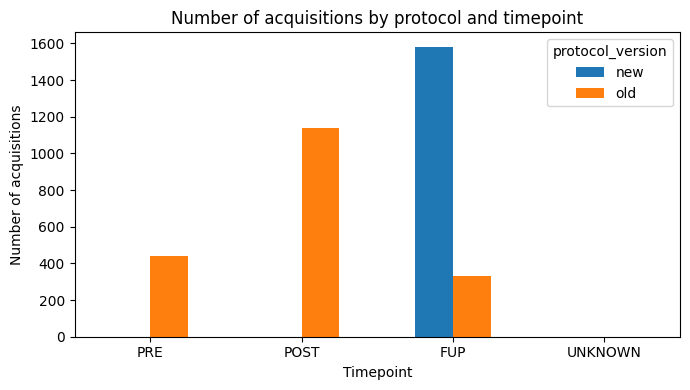

In [101]:
# Acquisitions by protocol and timepoint
acq_by_timepoint_df = (
    timepoint_summary_df.pivot(
        index="timepoint",
        columns="protocol_version",
        values="n_acquisitions",
    )
    .reindex(AUDIT_TIMEPOINT_SEQUENCE)
    .fillna(0)
)

_audit_plot_grouped_bar(
    pivot_df=acq_by_timepoint_df,
    title="Number of acquisitions by protocol and timepoint",
    xlabel="Timepoint",
    ylabel="Number of acquisitions",
    figsize=(7, 4),
)


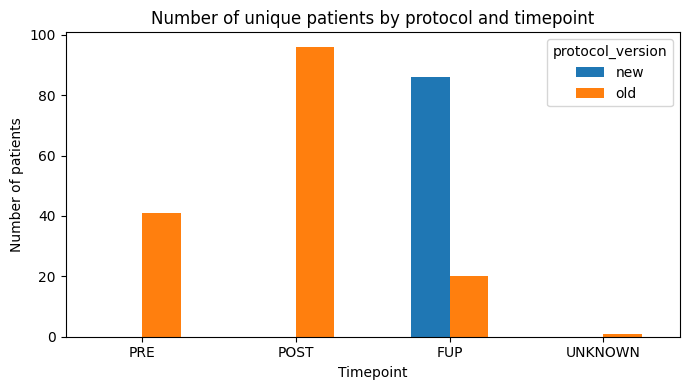

In [102]:
# Unique patients by protocol and timepoint
patients_by_timepoint_df = (
    timepoint_summary_df.pivot(
        index="timepoint",
        columns="protocol_version",
        values="n_patients",
    )
    .reindex(AUDIT_TIMEPOINT_SEQUENCE)
    .fillna(0)
)

_audit_plot_grouped_bar(
    pivot_df=patients_by_timepoint_df,
    title="Number of unique patients by protocol and timepoint",
    xlabel="Timepoint",
    ylabel="Number of patients",
    figsize=(7, 4),
)

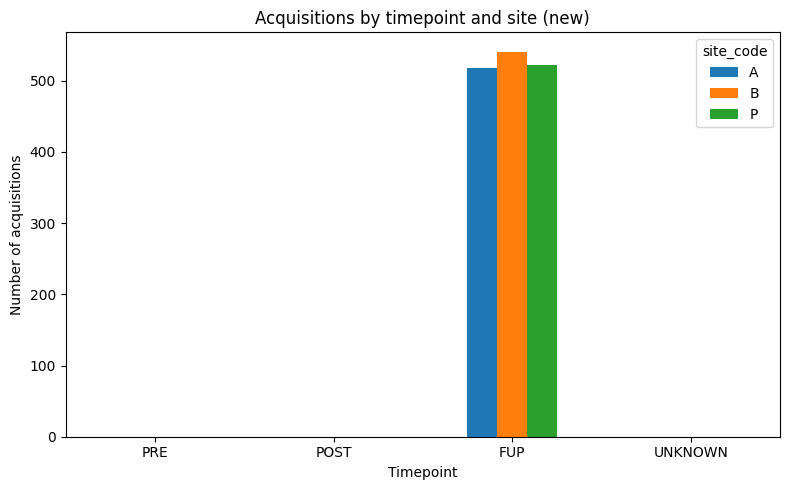

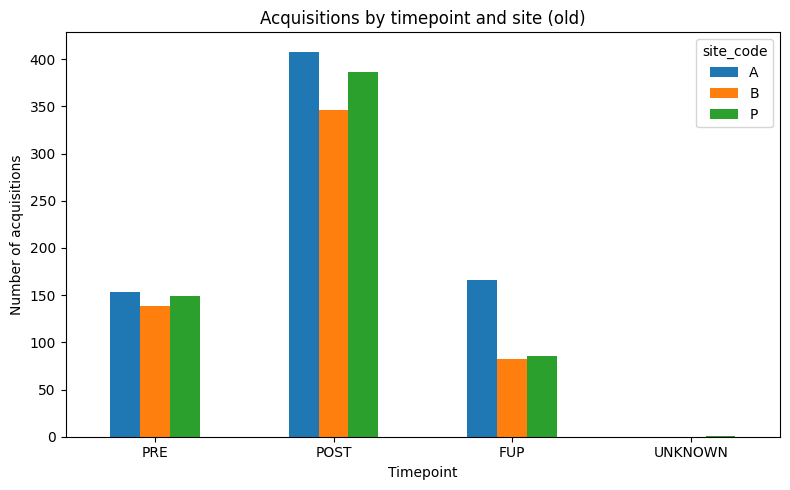

In [103]:
# Site x timepoint bar plots
_audit_plot_site_timepoint_bars(site_timepoint_summary_df)

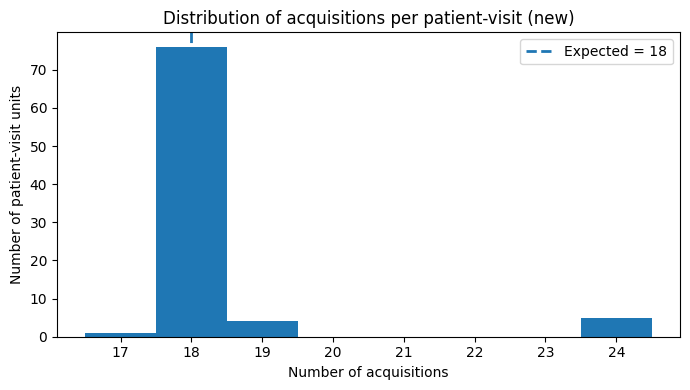

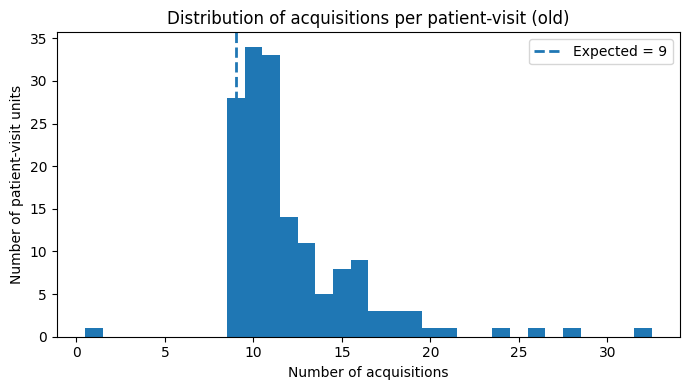

In [104]:
# Distribution of acquisitions per patient-visit
_audit_plot_patient_visit_histograms(patient_visit_counts_df)

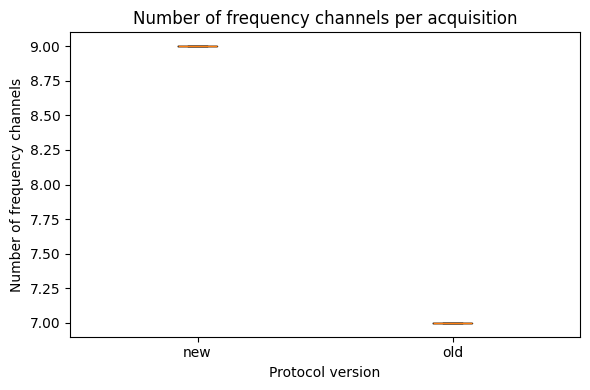

In [105]:
# Distribution of number of frequency channels
_audit_plot_frequency_channel_boxplot(audit_signals_df)

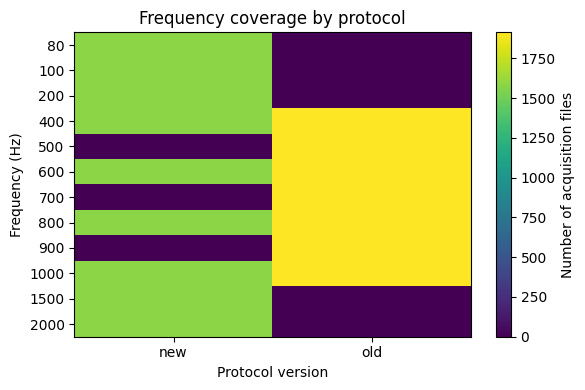

In [106]:
# Frequency coverage heatmap
_audit_plot_frequency_heatmap(frequency_coverage_df)

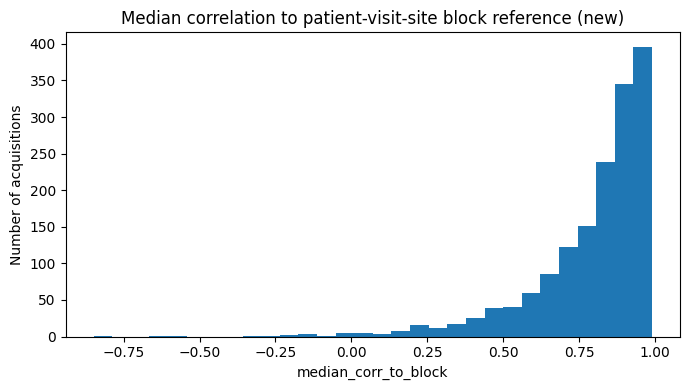

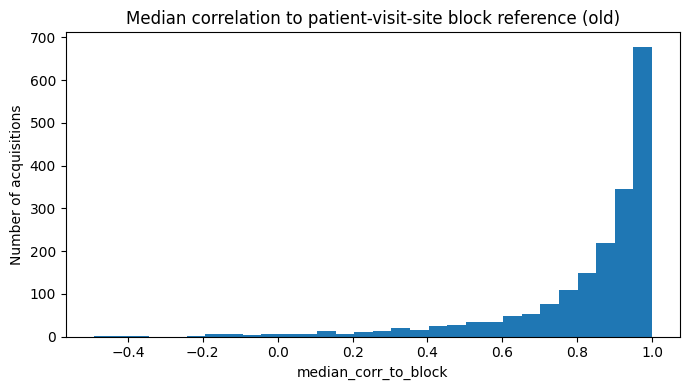

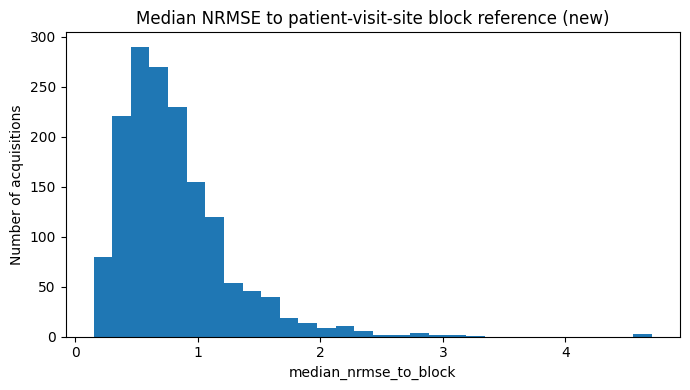

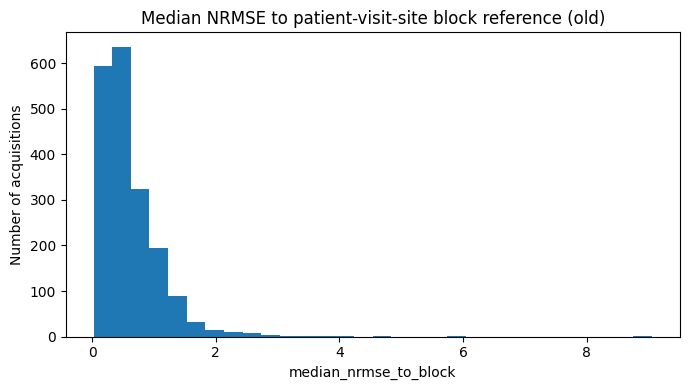

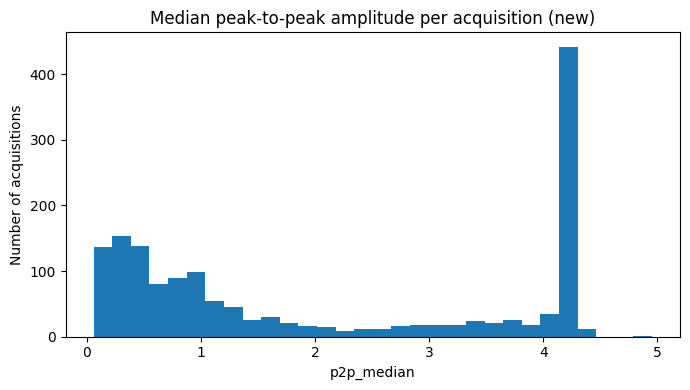

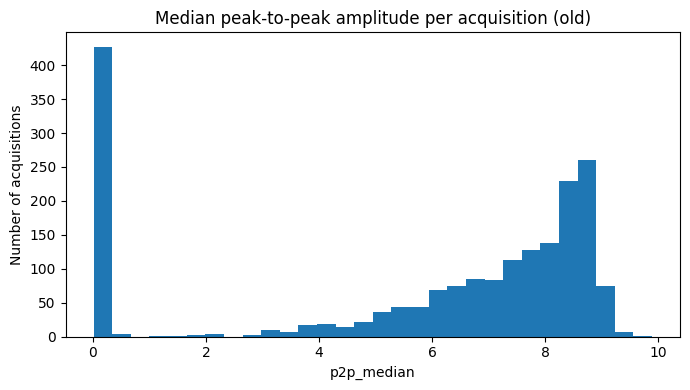

In [107]:
# Quality metric distributions
_audit_plot_quality_metric_histogram(
    quality_audit_df=quality_audit_df,
    metric_col="median_corr_to_block",
    title_prefix="Median correlation to patient-visit-site block reference",
    bins=30,
)

_audit_plot_quality_metric_histogram(
    quality_audit_df=quality_audit_df,
    metric_col="median_nrmse_to_block",
    title_prefix="Median NRMSE to patient-visit-site block reference",
    bins=30,
)

_audit_plot_quality_metric_histogram(
    quality_audit_df=quality_audit_df,
    metric_col="p2p_median",
    title_prefix="Median peak-to-peak amplitude per acquisition",
    bins=30,
)

## 2.11. Optional waveform examples


Waveform examples by protocol, site and frequency
Timepoint used for comparison: FUP
Frequencies requested: [800]

===== Frequency: 800 Hz =====
Plotting: protocol=old, site=A, freq=800 Hz, timepoint=FUP, n=166


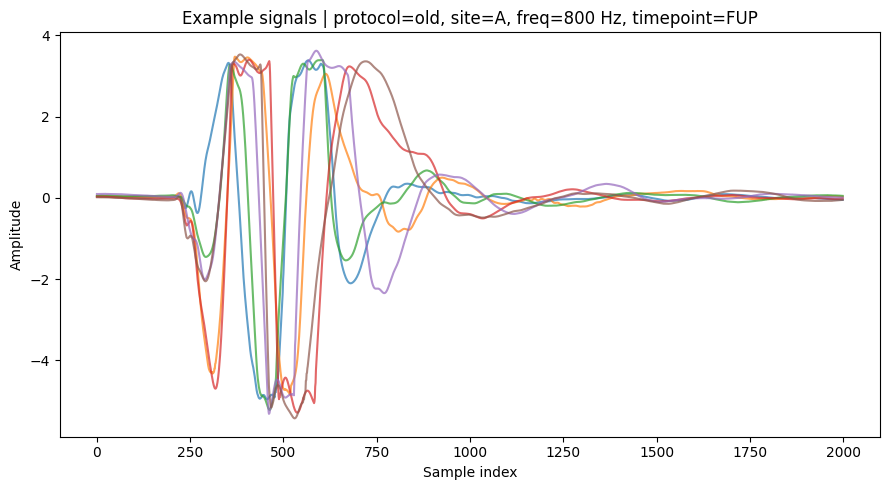

Plotting: protocol=old, site=B, freq=800 Hz, timepoint=FUP, n=82


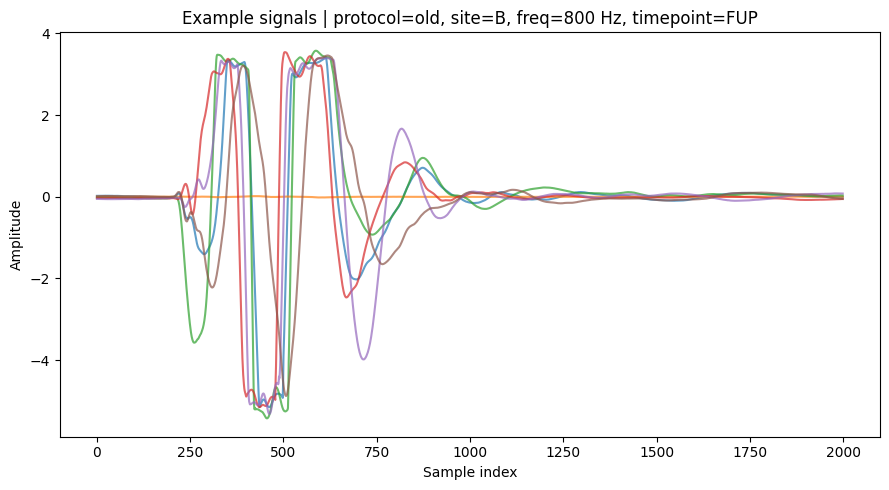

Plotting: protocol=old, site=P, freq=800 Hz, timepoint=FUP, n=85


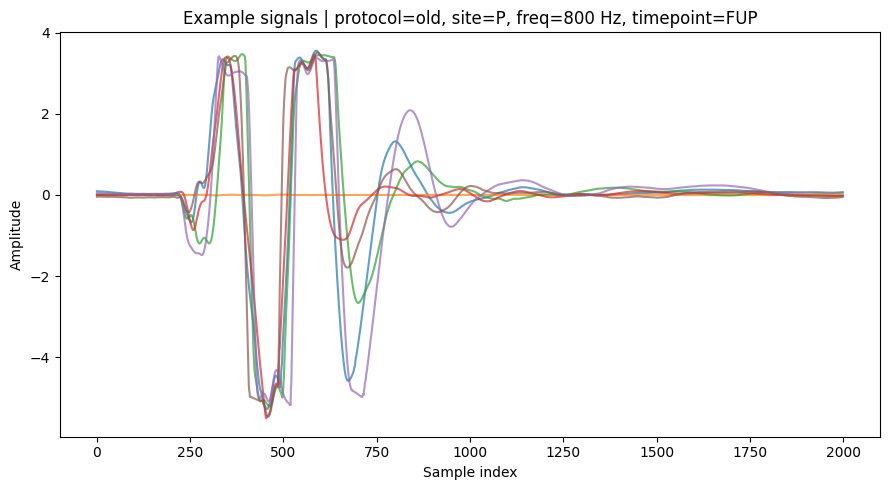

Plotting: protocol=new, site=A, freq=800 Hz, timepoint=FUP, n=518


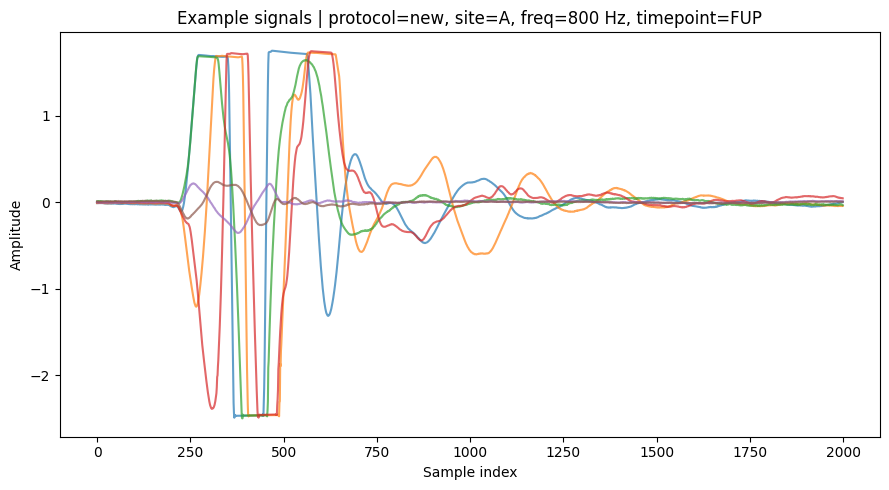

Plotting: protocol=new, site=B, freq=800 Hz, timepoint=FUP, n=541


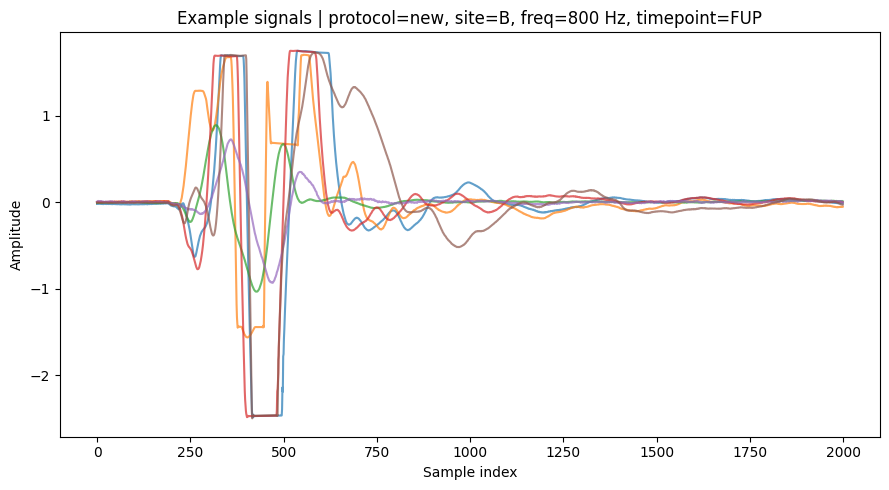

Plotting: protocol=new, site=P, freq=800 Hz, timepoint=FUP, n=522


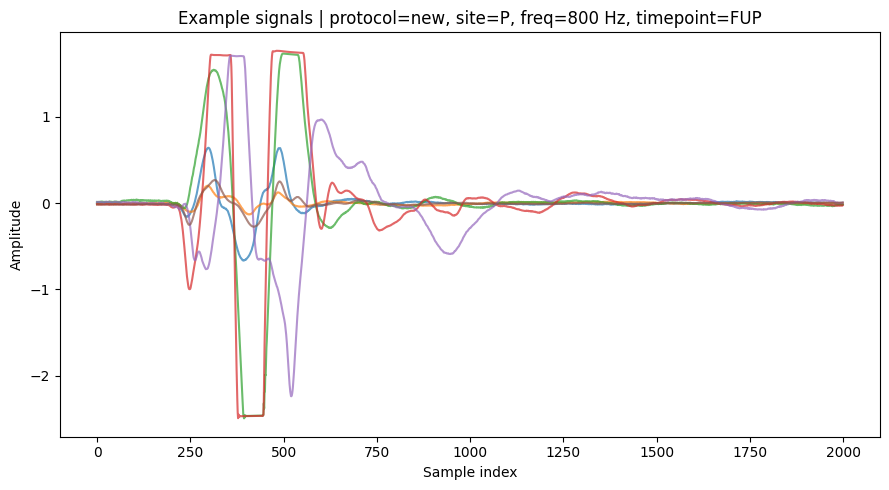

In [108]:
## Optional waveform examples
# Visual comparison by protocol and anatomical site
# We use FUP because it is the most populated common timepoint across protocols.
# To keep the section clean, start with one shared frequency (800 Hz).
# You can later change EXAMPLE_FREQUENCIES to [600, 800] if you want both.

EXAMPLE_TIMEPOINT = "FUP"
EXAMPLE_FREQUENCIES = [800]   # change to [600, 800] if needed
EXAMPLE_PROTOCOLS = ["old", "new"]
EXAMPLE_SITES = ["A", "B", "P"]
N_EXAMPLES = 6

print("\nWaveform examples by protocol, site and frequency")
print(f"Timepoint used for comparison: {EXAMPLE_TIMEPOINT}")
print(f"Frequencies requested: {EXAMPLE_FREQUENCIES}")

for frequency_hz in EXAMPLE_FREQUENCIES:
    print(f"\n===== Frequency: {frequency_hz} Hz =====")

    for protocol_version in EXAMPLE_PROTOCOLS:
        for site_code in EXAMPLE_SITES:

            subset_mask = (
                (audit_signals_df["protocol_version"] == protocol_version) &
                (audit_signals_df["site_code"] == site_code) &
                (audit_signals_df["timepoint"].astype(str) == EXAMPLE_TIMEPOINT) &
                audit_signals_df["freq_to_array"].map(
                    lambda d: isinstance(d, dict) and frequency_hz in d
                )
            )

            subset_n = int(subset_mask.sum())

            if subset_n == 0:
                print(
                    f"Skipped: protocol={protocol_version}, "
                    f"site={site_code}, freq={frequency_hz} Hz, "
                    f"timepoint={EXAMPLE_TIMEPOINT} -> no available signals"
                )
                continue

            print(
                f"Plotting: protocol={protocol_version}, "
                f"site={site_code}, freq={frequency_hz} Hz, "
                f"timepoint={EXAMPLE_TIMEPOINT}, n={subset_n}"
            )

            _audit_plot_signal_examples(
                signals_df=audit_signals_df,
                protocol_version=protocol_version,
                site_code=site_code,
                frequency_hz=frequency_hz,
                timepoint=EXAMPLE_TIMEPOINT,
                n_examples=N_EXAMPLES,
                normalise=False,
            )


Normalised waveform examples at 800 Hz (FUP)


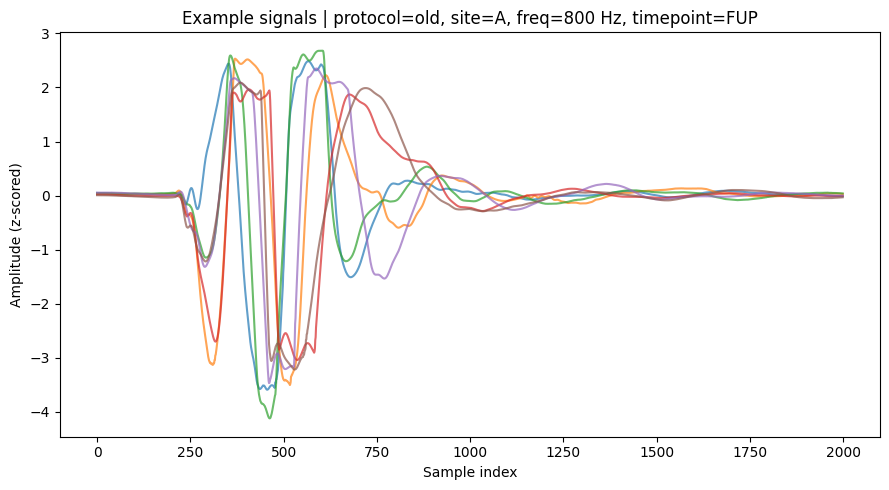

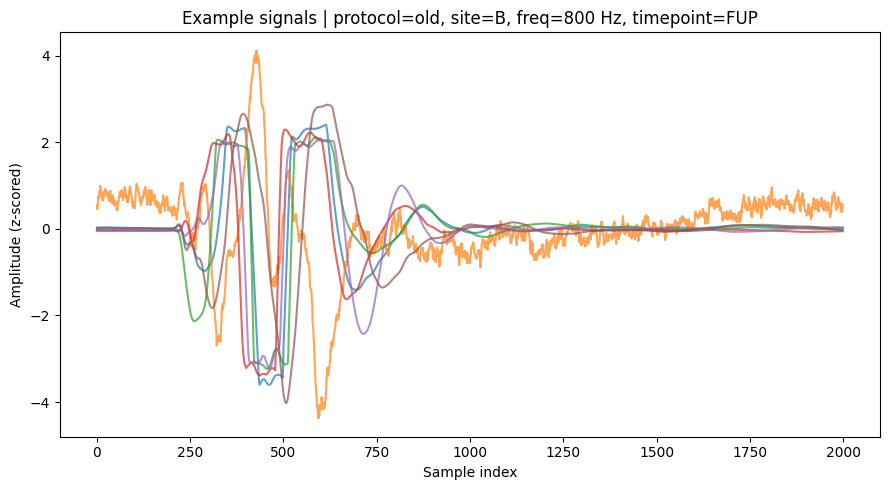

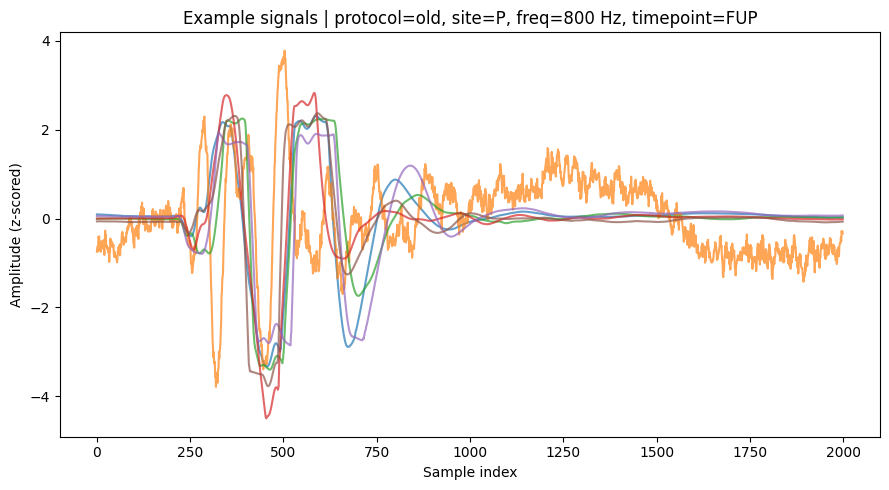

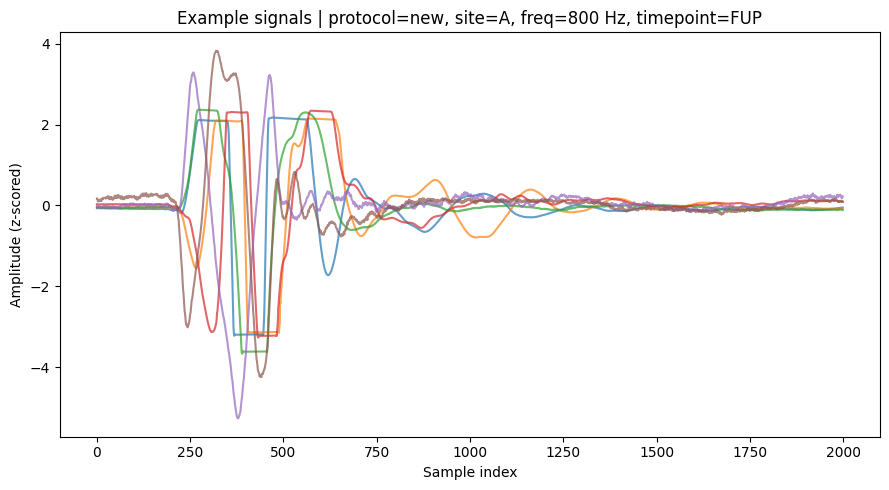

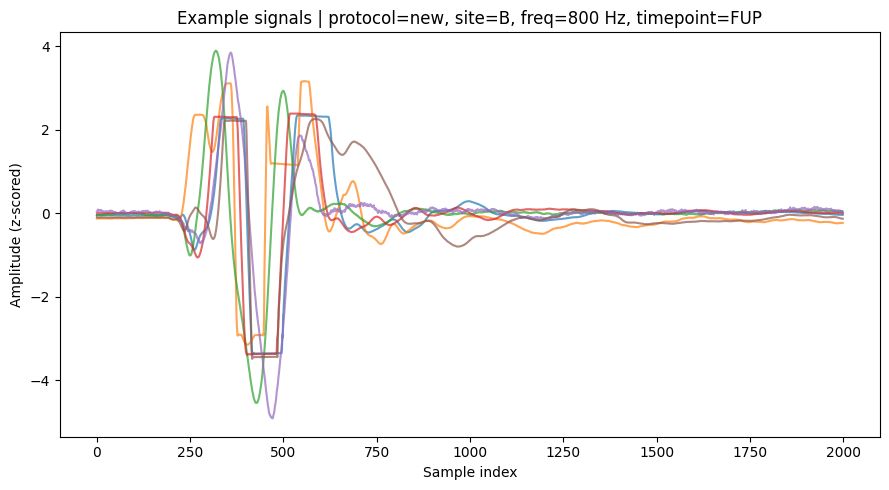

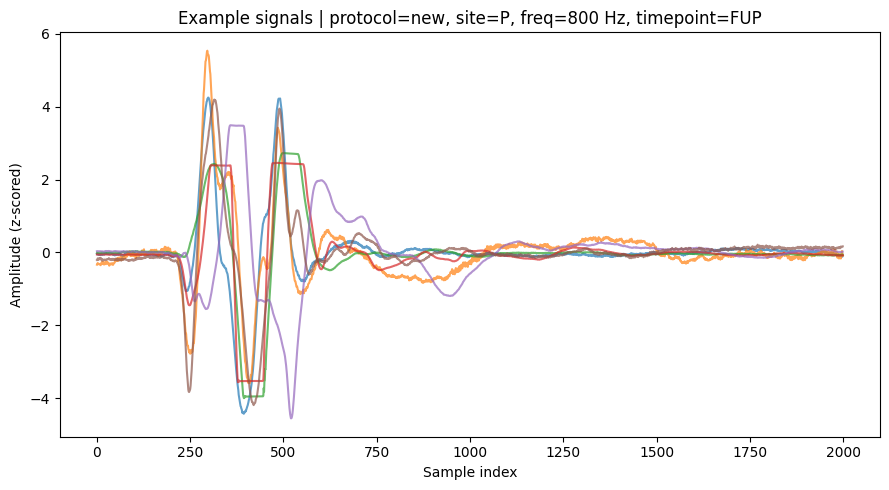

In [109]:
## Optional normalised waveform examples
# Same comparison, but z-scored to focus on morphology rather than absolute amplitude.

NORMALISED_FREQUENCY = 800
NORMALISED_TIMEPOINT = "FUP"

print(f"\nNormalised waveform examples at {NORMALISED_FREQUENCY} Hz ({NORMALISED_TIMEPOINT})")

for protocol_version in EXAMPLE_PROTOCOLS:
    for site_code in EXAMPLE_SITES:

        subset_mask = (
            (audit_signals_df["protocol_version"] == protocol_version) &
            (audit_signals_df["site_code"] == site_code) &
            (audit_signals_df["timepoint"].astype(str) == NORMALISED_TIMEPOINT) &
            audit_signals_df["freq_to_array"].map(
                lambda d: isinstance(d, dict) and NORMALISED_FREQUENCY in d
            )
        )

        if int(subset_mask.sum()) == 0:
            continue

        _audit_plot_signal_examples(
            signals_df=audit_signals_df,
            protocol_version=protocol_version,
            site_code=site_code,
            frequency_hz=NORMALISED_FREQUENCY,
            timepoint=NORMALISED_TIMEPOINT,
            n_examples=N_EXAMPLES,
            normalise=True,
        )